In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

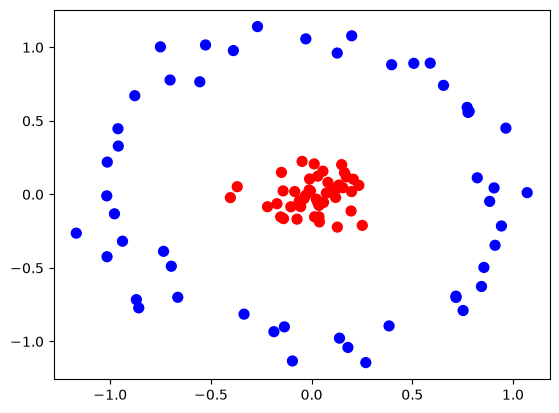

In [2]:

from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)


In [4]:

classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [5]:

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6

In [6]:

zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\husna\AppData\Local\Temp\ipykernel_15616\2475872515.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


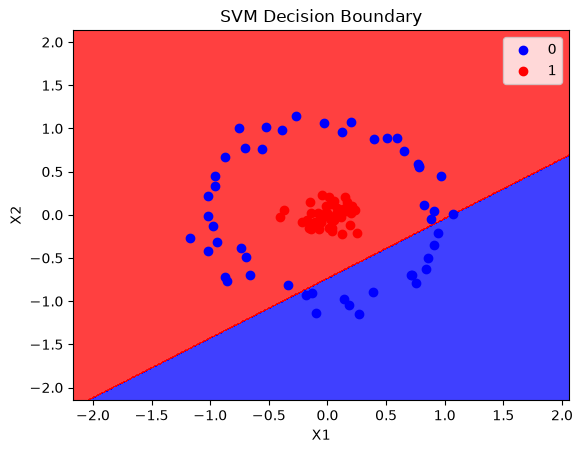

In [7]:

plot_decision_boundary(X, y, classifier)

In [8]:

def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

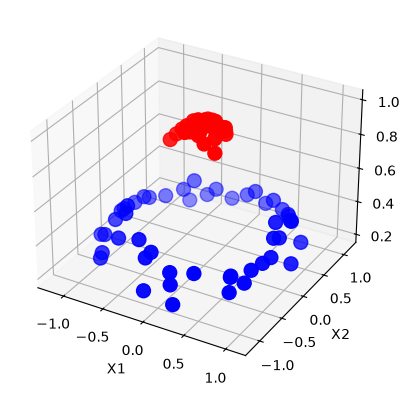

In [9]:

plot_3d_plot(X,y)

In [10]:

rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [11]:

accuracy_score(y_test, y_pred)

1.0

C:\Users\husna\AppData\Local\Temp\ipykernel_15616\2475872515.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


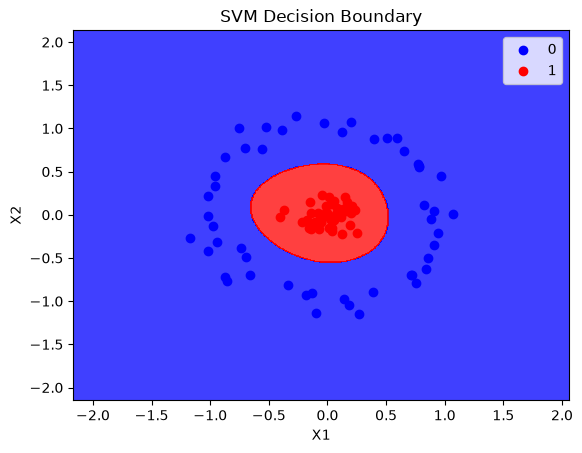

In [12]:
plot_decision_boundary(X, y, rbf_classifier)

In [13]:

poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [14]:

accuracy_score(y_test, y_pred)

1.0

C:\Users\husna\AppData\Local\Temp\ipykernel_15616\2475872515.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


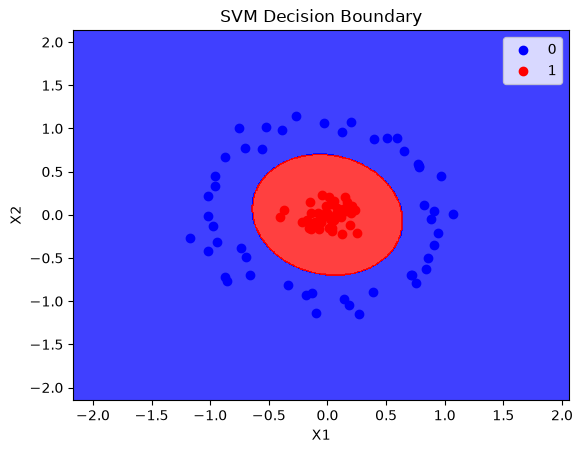

In [15]:

plot_decision_boundary(X, y, poly_classifier)

In [16]:

X

array([[-1.16855415, -0.26381974],
       [ 0.84353062, -0.62640586],
       [ 1.07044929,  0.01164599],
       [-1.01706058, -0.0099623 ],
       [ 0.71716495, -0.70104401],
       [ 0.14932583,  0.20226072],
       [ 0.65504277,  0.7412466 ],
       [ 0.78256114,  0.56376864],
       [ 0.77232046,  0.59155566],
       [-0.13517662, -0.90081862],
       [-0.85829284, -0.7715969 ],
       [ 0.1272862 ,  0.96096904],
       [ 0.39738585,  0.88156673],
       [-0.96153914,  0.44639057],
       [ 0.1033506 ,  0.03935539],
       [-0.18713737, -0.93368232],
       [ 0.94259977, -0.21499638],
       [ 0.77688286,  0.55712861],
       [-0.0577016 , -0.07755835],
       [-0.15357077, -0.15327512],
       [ 0.03513934, -0.067305  ],
       [-0.38848609,  0.97776043],
       [-0.70253636,  0.77767436],
       [ 0.03037288,  0.1236306 ],
       [ 0.19909357,  1.07830751],
       [ 0.50741354,  0.89095509],
       [ 0.82266538,  0.11277208],
       [ 0.38468936, -0.89450353],
       [ 0.13854425,

In [17]:

np.exp(-(X**2)).sum(1)

array([1.18801427, 1.16633022, 1.31781421, 1.35533599, 1.20963466,
       1.93786466, 1.22837639, 1.26977014, 1.25547918, 1.42609596,
       1.03007004, 1.38107072, 1.3136317 , 1.21604003, 1.98782785,
       1.38379944, 1.36610312, 1.28002776, 1.99067882, 1.95347251,
       1.99424627, 1.24433683, 1.15664694, 1.9839096 , 1.27376326,
       1.225129  , 1.49561476, 1.31171088, 1.3653629 , 1.19194889,
       1.9487885 , 1.99896413, 1.9667583 , 1.96401996, 1.9519082 ,
       1.99304251, 1.31015451, 1.2108113 , 1.98544367, 1.98677485,
       1.98260087, 1.99944806, 1.99421189, 1.94268202, 1.20034838,
       1.31757136, 1.30636933, 1.98232752, 1.94746593, 1.99351439,
       1.99775674, 1.94606835, 1.43807555, 1.93547007, 1.97560678,
       1.20246825, 1.95781057, 1.8950324 , 1.10368298, 1.29565558,
       1.84936052, 1.97671548, 1.44316379, 1.99018315, 1.9742158 ,
       1.99836807, 1.97234233, 1.32320064, 1.06796084, 1.29136879,
       1.1139662 , 1.98902978, 1.9918585 , 1.94962508, 1.95401

In [18]:

X_new=np.exp(-(X**2))

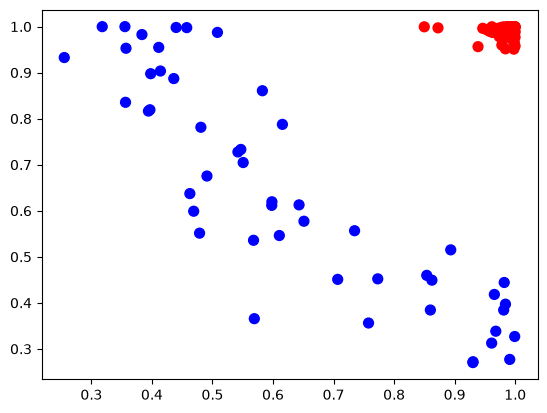

In [19]:

plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')